# Optimizers

Optimizers are the algorithms that update a model's parameters to minimize a function. Building on Gradient Descent, this notebook implements and visualizes more advanced optimizers, like Stochastic Gradient Descent (SGD), RMSprop, and Adam. Rather than fitting a dataset, we will watch each optimizer navigate a 3D surface, stepping from a shared starting point toward lower values of the function. This lets us compare how each optimizer behaves on the exact same problem.

Importing the libraries

In [1]:
# import numpy as np
import autograd.numpy as np
from autograd import grad
from autograd import elementwise_grad as egrad

%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from celluloid import Camera
import scienceplots
from IPython.display import Image

np.random.seed(0)
plt.style.use(["science", "no-latex"])

## Training Dataset

Instead of a dataset, our optimizers will minimize a mathematical function. We will use the surface:

$z = x^2 - y^2$

This is a hyperbolic paraboloid, also known as a saddle. The surface curves upward along the $x$ axis and downward along the $y$ axis, creating a saddle point where the gradient is small in some directions. Saddle points are a classic challenge for optimizers: a naive optimizer can stall near the ridge, while adaptive optimizers escape more quickly. This makes the saddle a great way to compare optimizer behavior.

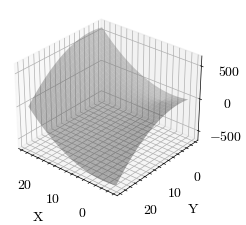

In [2]:
def surface_fn(X, Y):
    return X**2 - Y**2


def generate_function(dims, surface_fn):
    x = np.linspace(-5, 25, dims)
    y = np.linspace(-5, 25, dims)
    X, Y = np.meshgrid(x, y)
    Z = surface_fn(X, Y)

    return X, Y, Z


dims = 25
X, Y, Z = generate_function(dims, surface_fn)

# Visualize the Hyperbolic Paraboloid
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.view_init(30, 130)

ax.plot_surface(X, Y, Z, color="grey", alpha=0.4)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

## Optimizers

Every optimizer in this notebook follows the same core idea as gradient descent: repeatedly step the parameters $\theta$ in the direction that decreases the function the most, which is the negative gradient. A single update step is:

$
\begin{align*}
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} f(\theta_t)
\end{align*}
$

where $\eta$ is the learning rate and $\nabla_{\theta} f(\theta_t)$ is the gradient of the function with respect to the parameters at step $t$. The optimizers below differ in how they use the gradient, such as accumulating past gradients (momentum) or scaling each parameter's step by a running estimate of its gradient magnitude (adaptive learning rates).

### Stochastic Gradient Descent (SGD)

SGD is the simplest optimizer. It takes a step directly proportional to the negative gradient, scaled by the learning rate:

$
\begin{align*}
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} f(\theta_t)
\end{align*}
$

SGD treats every parameter and every direction the same. Because the step depends only on the current gradient and a fixed learning rate, SGD can move very slowly in directions where the gradient is small, such as along the flat ridge of a saddle.

### RMSprop

RMSprop gives each parameter its own adaptive learning rate by keeping an exponentially decaying average of recent squared gradients, $s_t$:

$
\begin{align*}
s_{t+1} &= \beta s_t + (1 - \beta) (\nabla_{\theta} f(\theta_t))^2 \\
\theta_{t+1} &= \theta_t - \frac{\eta}{\sqrt{s_{t+1}} + \epsilon} \nabla_{\theta} f(\theta_t)
\end{align*}
$

Dividing by $\sqrt{s_{t+1}}$ shrinks the step for parameters with large, noisy gradients and enlarges it for parameters with small gradients. The small constant $\epsilon$ prevents division by zero. This adaptivity helps RMSprop make steady progress even where SGD stalls.

### Adam

Adam (Adaptive Moment Estimation) combines momentum with RMSprop's adaptive learning rates. It tracks an exponentially decaying average of the gradients (the first moment $m_t$) and of the squared gradients (the second moment $v_t$):

$
\begin{align*}
m_{t+1} &= \beta_1 m_t + (1 - \beta_1) \nabla_{\theta} f(\theta_t) \\
v_{t+1} &= \beta_2 v_t + (1 - \beta_2) (\nabla_{\theta} f(\theta_t))^2
\end{align*}
$

Because $m_t$ and $v_t$ start at zero, they are biased toward zero early in training, so Adam applies a bias correction:

$
\begin{align*}
\hat{m}_{t+1} = \frac{m_{t+1}}{1 - \beta_1^{t+1}}, \quad \hat{v}_{t+1} = \frac{v_{t+1}}{1 - \beta_2^{t+1}}
\end{align*}
$

The parameters are then updated using the corrected moments:

$
\begin{align*}
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_{t+1}} + \epsilon} \hat{m}_{t+1}
\end{align*}
$

Combining momentum and adaptive scaling makes Adam a robust default optimizer that often converges quickly across many problems.

## Graphing functions

Let's define helper functions to plot the graphs. `create_scatter_and_3d_plot` sets up two views: a 2D plot tracking each optimizer's $z$ value over the epochs, and a 3D plot showing each optimizer's current position on the surface. `show_epoch` controls how often a frame is captured for the animation, sampling frequently early in training and less often later.

In [5]:
def create_scatter_and_3d_plot():
    fig, ax = plt.subplots(1, 3, figsize=(16 / 9.0 * 4, 4 * 1))
    fig.suptitle("Optimizers")

    ylim = (-5, 25)
    zlim = (-650, 550)

    ax[0].set_xlabel("Epoch", fontweight="normal")
    ax[0].set_ylabel("Z", fontweight="normal")
    ax[0].set_title("Z Value")
    ax[0].set_ylim((-650, 450))

    ax[1].axis("off")
    ax[2].axis("off")

    ax[2] = fig.add_subplot(1, 2, 2, projection="3d")
    ax[2].set_xlabel("X")
    ax[2].set_ylabel("Y")
    ax[2].set_zlabel("Z")
    ax[2].set_title("Current Position")
    ax[2].view_init(30, 130)
    ax[2].set_xlim(ylim)
    ax[2].set_ylim(ylim)
    ax[2].set_zlim(zlim)

    camera = Camera(fig)
    return ax[0], ax[2], camera


def show_epoch(epoch):
    return (
        (epoch < 25 and epoch % 2 == 0)
        or (epoch < 50 and epoch % 5 == 0)
        or (epoch <= 100 and epoch % 15 == 0)
        or (epoch <= 500 and epoch % 45 == 0)
        or (epoch <= 1000 and epoch % 50 == 0)
        or epoch % 250 == 0
    )

## PyTorch Implementation

Machine learning libraries, such as PyTorch, provide highly optimized implementations of these optimizers. We will use PyTorch to run SGD, Adam, and RMSprop on the same surface and compare their trajectories.

In [9]:
import torch
import torch.nn as nn

torch.manual_seed(0)

We represent the optimization problem as a small model whose only parameters are the coordinates of a point on the surface. The `forward` method evaluates the surface function at the current point, which is the value we want to minimize.

In [10]:
class TorchNet(nn.Module):
    def __init__(self, initial_pt):
        super(TorchNet, self).__init__()

        self.pts = torch.nn.Parameter(initial_pt)

    def forward(self, surface_fn):
        return surface_fn(self.pts[0], self.pts[1])

    def get_pts(self):
        return self.pts.detach().cpu().numpy()

The training function creates one model and one optimizer per optimizer type, all starting from the same initial point. In each epoch, it evaluates the surface at every optimizer's current point, backpropagates the gradient, and steps each optimizer. It records each optimizer's position and $z$ value so they can be animated side by side.

In [11]:
def torch_fit(
    optimizer_types, surface_fn, X, Y, Z, epochs, learning_rate, output_filename, colors
):
    torch_models = []
    torch_optimizers = []
    optimizer_names = list(optimizer_types.keys())

    z_idx = np.arange(1, epochs + 1)
    z_vals = [np.full(epochs, -1) for _ in range(len(optimizer_names))]

    for optimizer in optimizer_types.values():
        torch_model = TorchNet(initial_pt_tensor.clone()).to(device)
        torch_optimizer = optimizer(torch_model.parameters(), lr=learning_rate)

        torch_models.append(torch_model)
        torch_optimizers.append(torch_optimizer)

    z_ax, predictions_ax1, camera1 = create_scatter_and_3d_plot()

    for idx in range(epochs):
        predictions_legends = []
        z_legends = []

        for torch_idx, (model, optimizer) in enumerate(
            zip(torch_models, torch_optimizers)
        ):
            loss = model(surface_fn)

            # optimizer
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if show_epoch(idx):
                loss_np = np.maximum(-1000, loss.detach().cpu().numpy())

                model_pts = model.get_pts()
                predictions_legends_idx = predictions_ax1.scatter(
                    model_pts[0], model_pts[1], loss_np, color=colors[torch_idx]
                )
                predictions_legends.append(predictions_legends_idx)

                z_vals[torch_idx][idx] = loss_np
                visible_mse = z_vals[torch_idx] != -1

                z_legends_idx = z_ax.plot(
                    z_idx[visible_mse][: idx + 1],
                    z_vals[torch_idx][visible_mse][: idx + 1],
                    color=colors[torch_idx],
                    alpha=0.5,
                )
                z_legends.append(z_legends_idx)

        if show_epoch(idx):
            predictions_ax1.plot_surface(X, Y, Z, color="grey", alpha=0.3)
            predictions_ax1.legend(
                predictions_legends, optimizer_names, loc="upper right"
            )
            z_ax.legend(z_legends, optimizer_names, loc="upper right")

            camera1.snap()

    animation1 = camera1.animate()
    animation1.save(output_filename, writer="pillow")
    plt.show()

## Training the model

Let's train all three optimizers from the same starting point and compare them. We start near the saddle's ridge at $(20.75, 0.5)$, where the gradient along the $y$ axis is small. SGD, Adam, and RMSprop are each given the same learning rate, so the only difference is the update rule.

/tmp/ipykernel_61169/1343264862.py:54: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  z_ax.legend(z_legends, optimizer_names, loc="upper right")


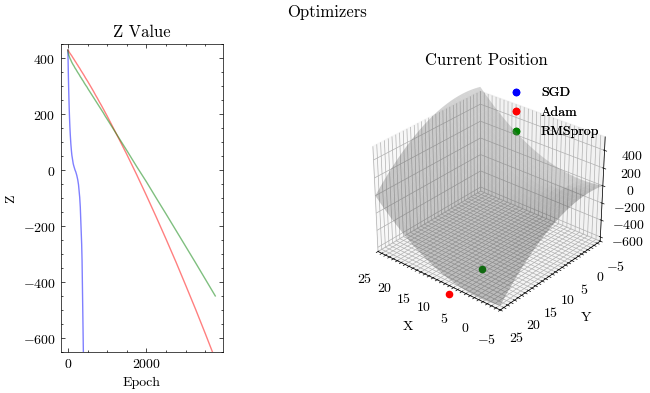

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

initial_pt = np.array([20.75, 0.5])
initial_pt_tensor = torch.tensor(initial_pt, device=device, dtype=torch.float32)

optimizer_types = {
    "SGD": torch.optim.SGD,
    "Adam": torch.optim.Adam,
    "RMSprop": torch.optim.RMSprop,
}
colors = ["blue", "red", "green"]

learning_rate = 0.005
epochs = 4000

output_filename_pytorch = "optimizers_pytorch.gif"
torch_fit(
    optimizer_types,
    surface_fn,
    X,
    Y,
    Z,
    epochs,
    learning_rate,
    output_filename_pytorch,
    colors,
)

## Output GIF

The visualization below shows all three optimizers descending the saddle surface from the same starting point. The right plot tracks each optimizer's current position in 3D, while the left plot shows how quickly each one drives the $z$ value down over the epochs. Comparing the curves highlights how SGD, RMSprop, and Adam navigate the same surface at different speeds.

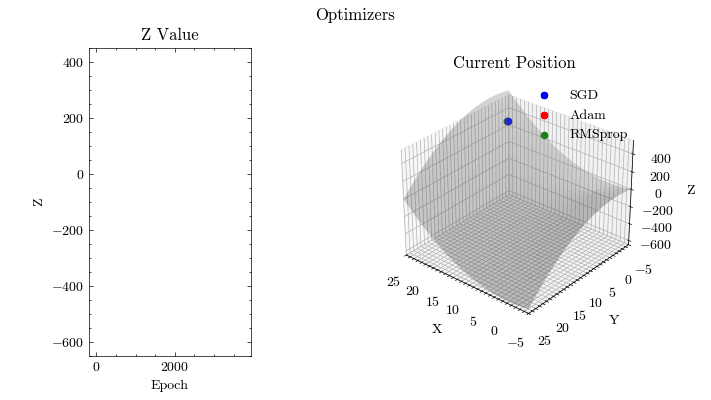

In [13]:
Image(filename=output_filename_pytorch)